TASK 3: DISTRIBUTION FITTING

📊 Column: copiesSold
  Best Fit: Gamma (p-value: 0.0000)
  Acceptable Fit (p > 0.05): No

📊 Column: price
  Best Fit: Gamma (p-value: 0.0000)
  Acceptable Fit (p > 0.05): No

📊 Column: revenue
  Best Fit: Gamma (p-value: 0.0000)
  Acceptable Fit (p > 0.05): No

📊 Column: avgPlaytime
  Best Fit: Gamma (p-value: 0.0000)
  Acceptable Fit (p > 0.05): No

📊 Column: reviewScore
  Best Fit: Gamma (p-value: 0.0000)
  Acceptable Fit (p > 0.05): No

📊 Column: steamId
  Best Fit: Uniform (p-value: 0.0000)
  Acceptable Fit (p > 0.05): No

📊 Column: revenue_per_copy
  Best Fit: Gamma (p-value: 0.0000)
  Acceptable Fit (p > 0.05): No


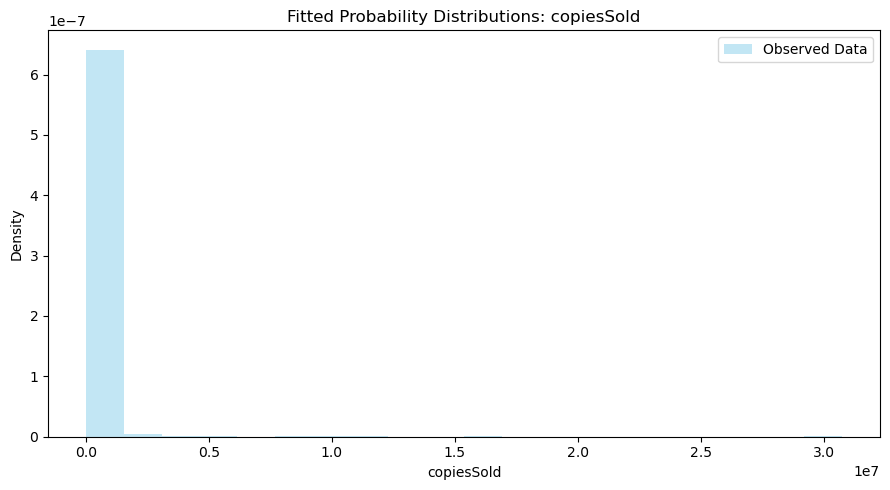

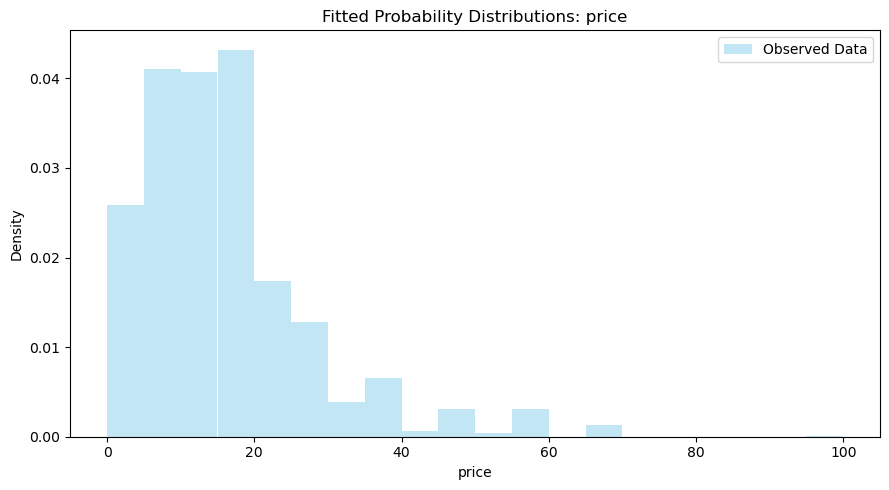

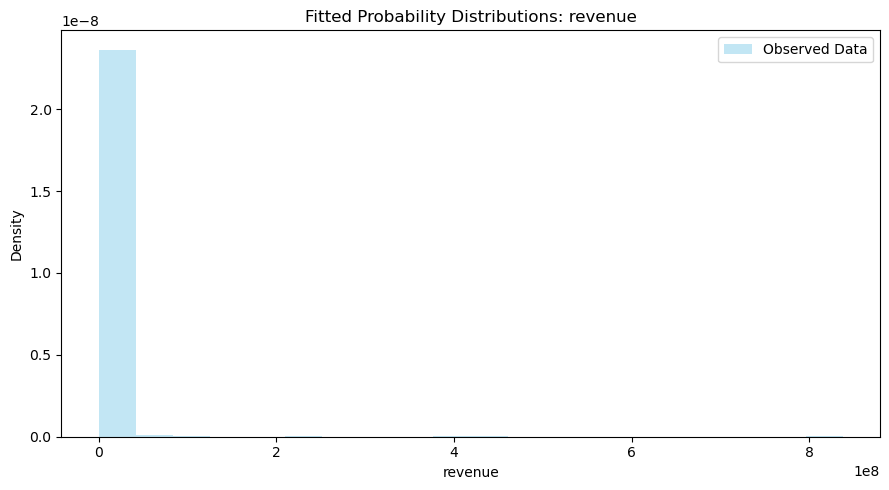

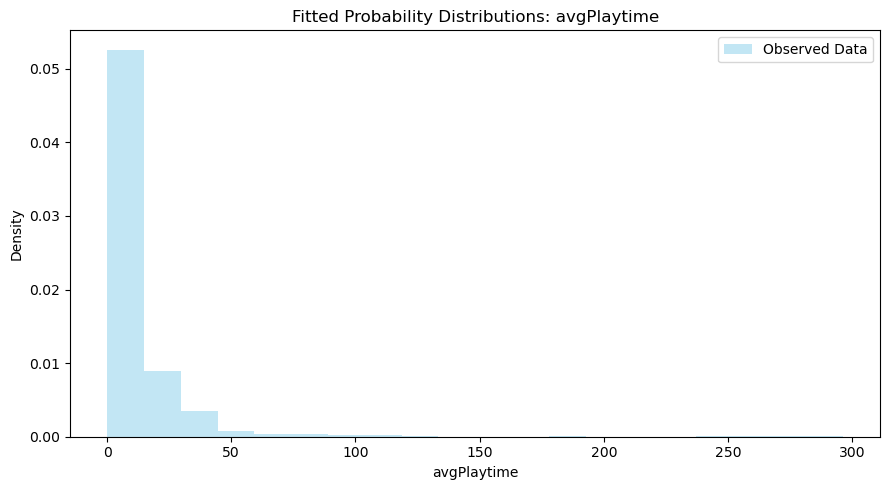

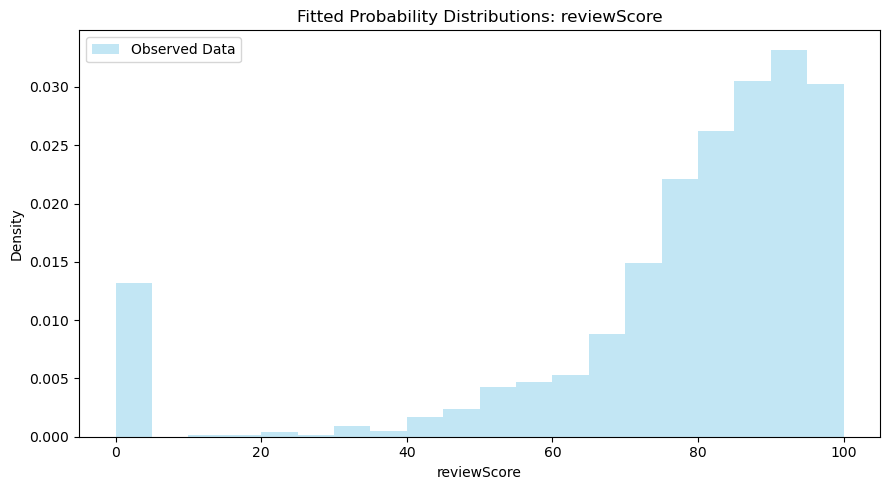

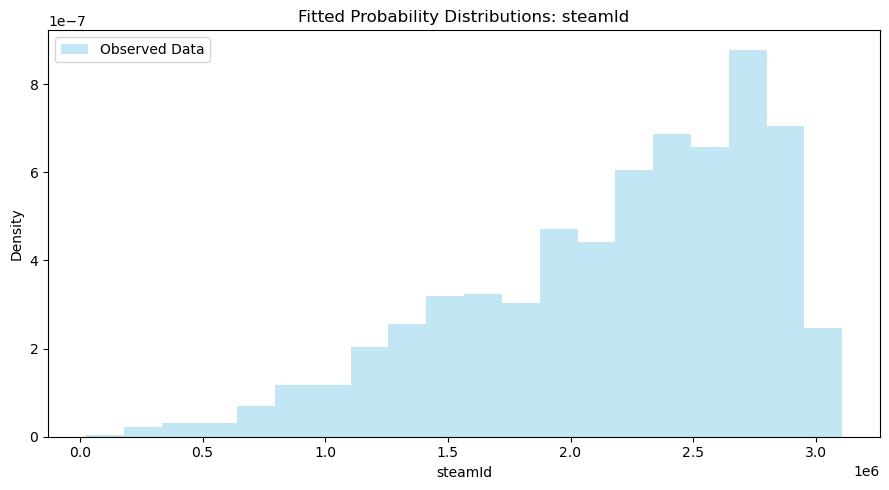

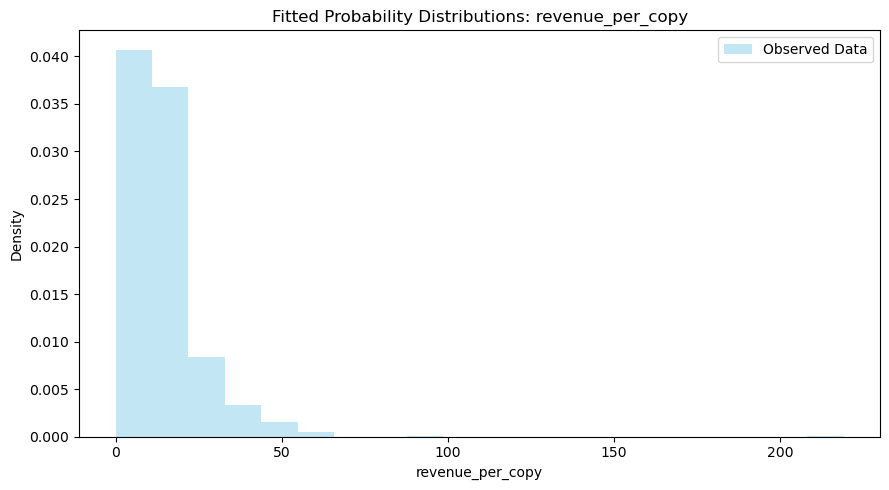


✅ Results successfully exported to 'reports/distribution_fitting_summary.csv'


In [5]:
import warnings
warnings.filterwarnings('ignore')
import sys
from pathlib import Path


project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from src.data_loader import DataLoader

# 1. Load Cleaned Dataset
loader = DataLoader()
df = pd.read_csv(loader.processed_dir / "cleaned_data.csv")

print("=" * 60)
print("TASK 3: DISTRIBUTION FITTING")
print("=" * 60)

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

# 2. Distribution Fitting Helper Function
def fit_distributions_to_column(data):
    """Fit candidate distributions and run Kolmogorov-Smirnov test."""
    results = {}
    distributions = {
        'Normal': stats.norm,
        'Exponential': stats.expon,
        'Gamma': stats.gamma,
        'Lognormal': stats.lognorm,
        'Uniform': stats.uniform
    }
    
    for dist_name, dist in distributions.items():
        try:
            params = dist.fit(data)
            # Compute KS statistic and p-value
            ks_stat, p_value = stats.kstest(data, dist_name.lower(), args=params)
            results[dist_name] = {
                'params': params,
                'ks_statistic': ks_stat,
                'p_value': p_value,
                'good_fit': p_value > 0.05
            }
        except Exception:
            results[dist_name] = {'error': 'Could not fit'}
            
    # Find distribution with highest p-value
    best_fit, best_p = None, -1
    for dist_name, result in results.items():
        if 'p_value' in result and result['p_value'] > best_p:
            best_p = result['p_value']
            best_fit = dist_name
            
    return results, best_fit, best_p

# 3. Fit All Numeric Columns
all_fitting_results = {}
for col in numeric_cols:
    data = df[col].dropna()
    if len(data) > 10:
        results, best_fit, best_p = fit_distributions_to_column(data)
        all_fitting_results[col] = {
            'results': results,
            'best_fit': best_fit,
            'best_p_value': best_p
        }
        print(f"\n📊 Column: {col}")
        print(f"  Best Fit: {best_fit} (p-value: {best_p:.4f})")
        print(f"  Acceptable Fit (p > 0.05): {'Yes' if best_p > 0.05 else 'No'}")

# 4. Visualization Generator
def plot_fitted_distributions(df, column, results):
    """Overlay valid fitted PDFs on column histogram."""
    data = df[column].dropna()
    plt.figure(figsize=(9, 5))
    
    # Plot empirical data histogram
    plt.hist(data, bins=20, density=True, alpha=0.5, color='skyblue', label='Observed Data')
    
    colors = ['crimson', 'forestgreen', 'darkorange', 'purple', 'saddlebrown']
    color_idx = 0
    
    x = np.linspace(data.min(), data.max(), 200)
    for dist_name, res in results.items():
        if 'params' in res and res['good_fit']:
            dist_obj = getattr(stats, dist_name.lower())
            pdf = dist_obj.pdf(x, *res['params'])
            plt.plot(x, pdf, color=colors[color_idx % len(colors)], 
                     linewidth=2, label=f"{dist_name} (p={res['p_value']:.3f})")
            color_idx += 1

    plt.title(f'Fitted Probability Distributions: {column}')
    plt.xlabel(column)
    plt.ylabel('Density')
    plt.legend()
    plt.tight_layout()
    plt.savefig(f'../reports/figures/distribution_fit_{column}.png', dpi=300, bbox_inches='tight')
    plt.show()

# Export visualizations for numeric attributes
for col in numeric_cols:
    if col in all_fitting_results:
        plot_fitted_distributions(df, col, all_fitting_results[col]['results'])

# 5. Export Summary CSV
summary_rows = []
for col, info in all_fitting_results.items():
    summary_rows.append({
        'column': col,
        'best_fit': info['best_fit'],
        'p_value': info['best_p_value'],
        'good_fit': info['best_p_value'] > 0.05
    })

pd.DataFrame(summary_rows).to_csv('../reports/distribution_fitting_summary.csv', index=False)
print("\n✅ Results successfully exported to 'reports/distribution_fitting_summary.csv'")